# 📈 Stock Trend Prediction — Dual-Head Transformer

**Architecture:** Temporal Transformer with two heads:
- 🔴 **Classification Head** → Trend Direction (UP / DOWN / NEUTRAL)
- 🔵 **Regression Head** → Next-day Close Price

**Data Schema:**
- `price_data` — OHLCV time-series core (date, stock_id, open, high, low, close, volume)
- `technical_features` — Derived features (ret_1D, ret_3D, ret_7D, rsi, macd, volatility_7D, volume_change)

**Sector Focus:** Banking (HDFC, SBI, ICICI, KOTAKBANK, AXISBANK)

---

## 📦 Section 1 — Install & Import Dependencies

In [1]:
# Install PyTorch (CPU) if not already installed
import importlib, subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

if importlib.util.find_spec('torch') is None:
    print('Installing PyTorch...')
    install('torch')
    print('Done.')
else:
    print('PyTorch already installed.')

PyTorch already installed.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, r2_score

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128


---
## 🏗️ Section 2 — Data Loading (Yahoo Finance → price_data format)

Downloads real OHLCV data via `yfinance` and reshapes the MultiIndex output into the `stock_id` long-format that the rest of the pipeline expects.

**Why the conversion is needed:** `yf.download()` returns columns like `('Close', 'HDFCBANK.NS')` — a MultiIndex with *(field, ticker)* levels. We unpack this with `.xs(ticker, axis=1, level=1)` per ticker and stack them into one long DataFrame with a `stock_id` column.

**To change stocks:** edit `TICKER_MAP` — key = friendly label, value = `.NS` ticker.

In [3]:
import subprocess, sys
try:
    import yfinance as yf
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'yfinance', '-q'])
    import yfinance as yf


# ════════════════════════════════════════════════════════════════
#  TICKER MAP  ←  edit this to change stocks / sector
#  key   = friendly stock_id used throughout the notebook
#  value = Yahoo Finance ticker symbol
# ════════════════════════════════════════════════════════════════
TICKER_MAP = {
    'HDFCBANK'  : 'HDFCBANK.NS',
    'IDFCFIRST' : 'IDFCFIRSTB.NS',
    'ICICI'     : 'ICICIBANK.NS',
    'KOTAK'     : 'KOTAKBANK.NS',
    'AXIS'      : 'AXISBANK.NS',
    'SBI': 'SBIN.NS',
    'INDUSIND': 'INDUSINDBK.NS',
    'UNION BANK' : 'UNIONBANK.NS',
    'FEDERAL' : 'FEDERALBNK.NS',
    'BANK OF BARODA' : 'BANKBARODA.NS',
    'PNB' : 'PNB.NS',
    'BANDHAN' : 'BANDHANBNK.NS',
    'CANARA' : 'CANBK.NS',
    'INDIAN' : 'INDIANB.NS',
    'UCO' : 'UCOBANK.NS',
    'BOI' : 'BANKINDIA.NS',
    'SOUTH' : 'SOUTHBANK.NS',
    'CBOI' : 'CENTRALBK.NS',
    'KARUR' : 'KARURVYSYA.NS',
    'J&K' : 'J&KBANK.NS',
    'YES' : 'YESBANK.NS',
    'EQUITAS' : 'EQUITASBNK.NS',
    'UJJIVANS' : 'UJJIVANSFB.NS',
    'BAJFINA' : 'BAJFINANCE.NS',
    'BAJFINS' : 'BAJAJFINSV.NS',
    'MUTHOOTFIN' : 'MUTHOOTFIN.NS',
    'MANAPPURAM' : 'MANAPPURAM.NS',
    'IIFL' : 'IIFL.NS'
}
STOCKS = list(TICKER_MAP.keys())   # friendly names used everywhere else


def yf_to_price_df(ticker_map, start='2021-01-01', end=None):
    """
    Download real OHLCV data from Yahoo Finance and reshape it into
    the long-format price_data table the pipeline expects:
        columns: date, stock_id, open, high, low, close, volume

    yfinance returns a MultiIndex DataFrame when multiple tickers
    are requested — this function unpacks that correctly.
    """
    tickers = list(ticker_map.values())
    reverse = {v: k for k, v in ticker_map.items()}   # NS-ticker → friendly id

    raw = yf.download(
        tickers,
        start=start,
        end=end,
        auto_adjust=True,   # adjusts for splits & dividends; removes 'Adj Close'
        progress=False,
    )

    # ── yfinance MultiIndex layout ──────────────────────────────
    # raw.columns = MultiIndex([('Close', 'HDFCBANK.NS'), ('Close', 'ICICIBANK.NS'), ...])
    # Level-0 = price field,  Level-1 = ticker symbol
    # ────────────────────────────────────────────────────────────
    records = []
    for ticker in tickers:
        stock_id = reverse[ticker]
        try:
            df_t = raw.xs(ticker, axis=1, level=1).copy()   # slice one ticker
        except KeyError:
            print(f'  ⚠️  {ticker} not found in download — skipping')
            continue

        df_t = df_t.rename(columns=str.lower)               # Close→close, etc.
        df_t.index.name = 'date'
        df_t = df_t.reset_index()
        df_t['date']     = pd.to_datetime(df_t['date']).dt.tz_localize(None)  # strip tz
        df_t['stock_id'] = stock_id

        # keep only the columns our pipeline needs
        df_t = df_t[['date', 'stock_id', 'open', 'high', 'low', 'close', 'volume']]
        df_t = df_t.dropna(subset=['close'])                # drop holiday gaps
        records.append(df_t)

    price_df = pd.concat(records, ignore_index=True)
    price_df = price_df.sort_values(['stock_id', 'date']).reset_index(drop=True)
    return price_df


def compute_technical_features(price_df):
    """
    Compute technical_features table from price_data.
    Returns: ret_1D, ret_3D, ret_7D, rsi, macd, volatility_7D, volume_change
    Expects columns: date, stock_id, open, high, low, close, volume
    """
    dfs = []
    for stock_id, grp in price_df.groupby('stock_id'):
        grp = grp.sort_values('date').copy()
        c = grp['close']
        v = grp['volume']

        grp['ret_1D']        = c.pct_change(1)
        grp['ret_3D']        = c.pct_change(3)
        grp['ret_7D']        = c.pct_change(7)
        grp['volatility_7D'] = c.pct_change().rolling(7).std()
        grp['volume_change'] = v.pct_change(1)

        # RSI (14-period)
        delta = c.diff()
        gain  = delta.clip(lower=0).rolling(14).mean()
        loss  = (-delta.clip(upper=0)).rolling(14).mean()
        rs    = gain / (loss + 1e-9)
        grp['rsi'] = 100 - (100 / (1 + rs))

        # MACD (12, 26)
        ema12 = c.ewm(span=12, adjust=False).mean()
        ema26 = c.ewm(span=26, adjust=False).mean()
        grp['macd'] = ema12 - ema26

        dfs.append(grp)

    return pd.concat(dfs).reset_index(drop=True)


# ─── Download & Process ──────────────────────────────────────────
print('Downloading real OHLCV data from Yahoo Finance...')
price_df  = yf_to_price_df(TICKER_MAP, start='2021-01-01')
full_data = compute_technical_features(price_df)
full_data = full_data.dropna().reset_index(drop=True)

print(f'price_data shape  : {price_df.shape}')
print(f'full_data shape   : {full_data.shape}')
print(f'Stocks            : {full_data.stock_id.unique()}')
print(f'Date range        : {full_data.date.min().date()} → {full_data.date.max().date()}')
full_data.head(3)

price_data shape  : (36120, 7)
full_data shape   : (35727, 14)
Stocks            : <StringArray>
[          'AXIS',        'BAJFINA',        'BAJFINS',        'BANDHAN',
 'BANK OF BARODA',            'BOI',         'CANARA',           'CBOI',
        'EQUITAS',        'FEDERAL',       'HDFCBANK',          'ICICI',
      'IDFCFIRST',           'IIFL',         'INDIAN',       'INDUSIND',
            'J&K',          'KARUR',          'KOTAK',     'MANAPPURAM',
     'MUTHOOTFIN',            'PNB',            'SBI',          'SOUTH',
            'UCO',       'UJJIVANS',     'UNION BANK',            'YES']
Length: 28, dtype: str
Date range        : 2021-01-21 → 2026-03-19


Price,date,stock_id,open,high,low,close,volume,ret_1D,ret_3D,ret_7D,volatility_7D,volume_change,rsi,macd
0,2021-01-21,AXIS,677.919445,692.110194,666.965183,673.039795,15849438,0.000148,0.028691,0.000222,0.017063,0.588022,67.880452,12.540327
1,2021-01-22,AXIS,667.214099,671.097907,636.143818,641.820129,21392223,-0.046386,-0.036262,-0.062954,0.022388,0.349715,55.624994,9.855035
2,2021-01-25,AXIS,651.280685,665.222474,636.691575,655.662415,21325345,0.021567,-0.025675,-0.026035,0.024709,-0.003126,47.985370,8.743094


---
## 🔍 Section 3 — Exploratory Data Analysis

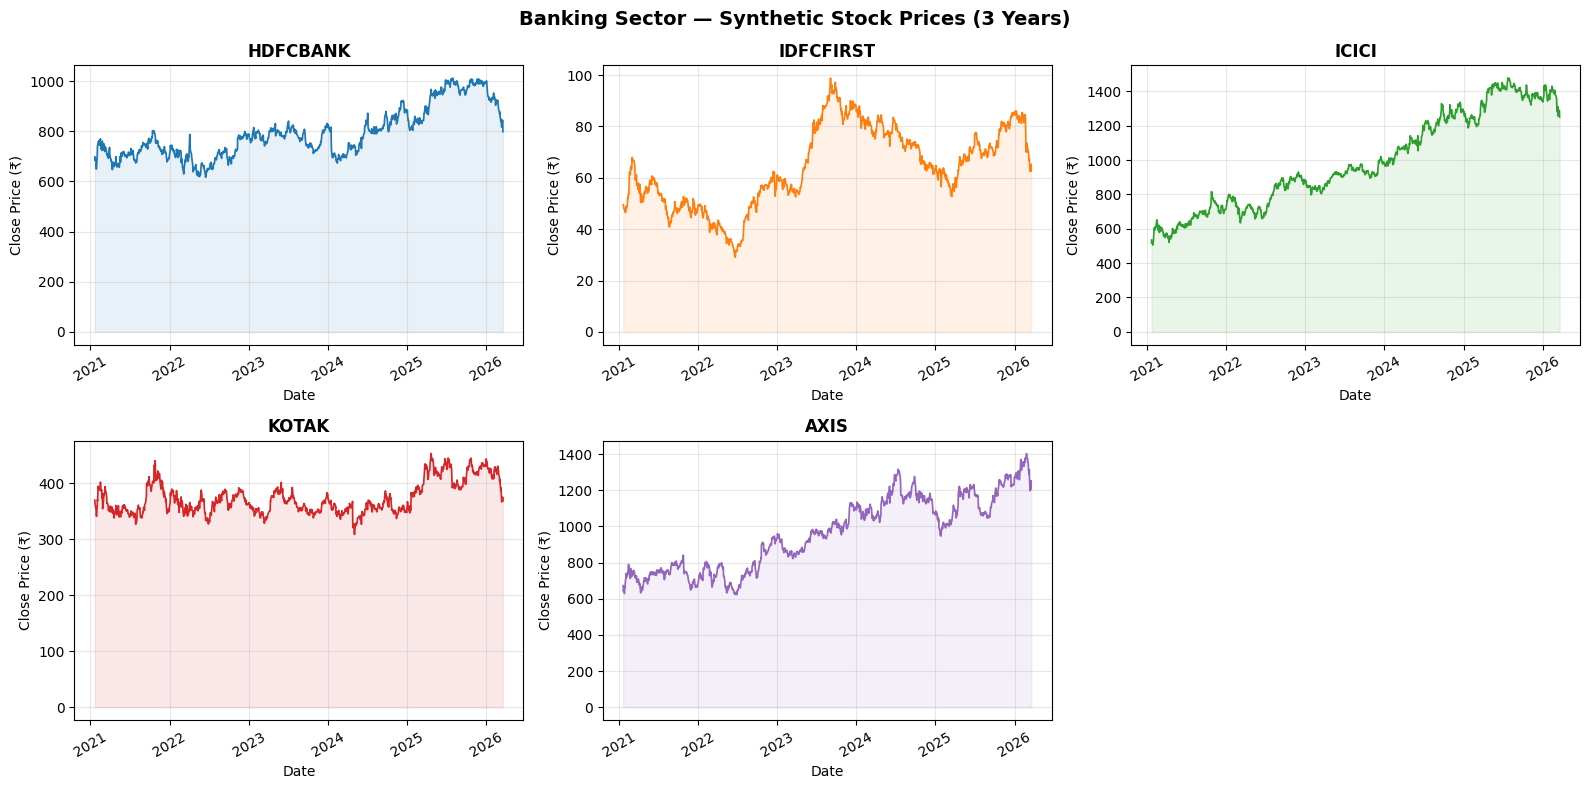

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Banking Sector — Synthetic Stock Prices (3 Years)', fontsize=14, fontweight='bold')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for ax, (stock, color) in zip(axes.flatten(), zip(STOCKS, colors)):
    df_s = full_data[full_data.stock_id == stock].sort_values('date')
    ax.plot(df_s['date'], df_s['close'], color=color, linewidth=1.2)
    ax.fill_between(df_s['date'], df_s['close'], alpha=0.1, color=color)
    ax.set_title(stock, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Close Price (₹)')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3)

axes[1, 2].axis('off')  # hide last empty
plt.tight_layout()
plt.show()

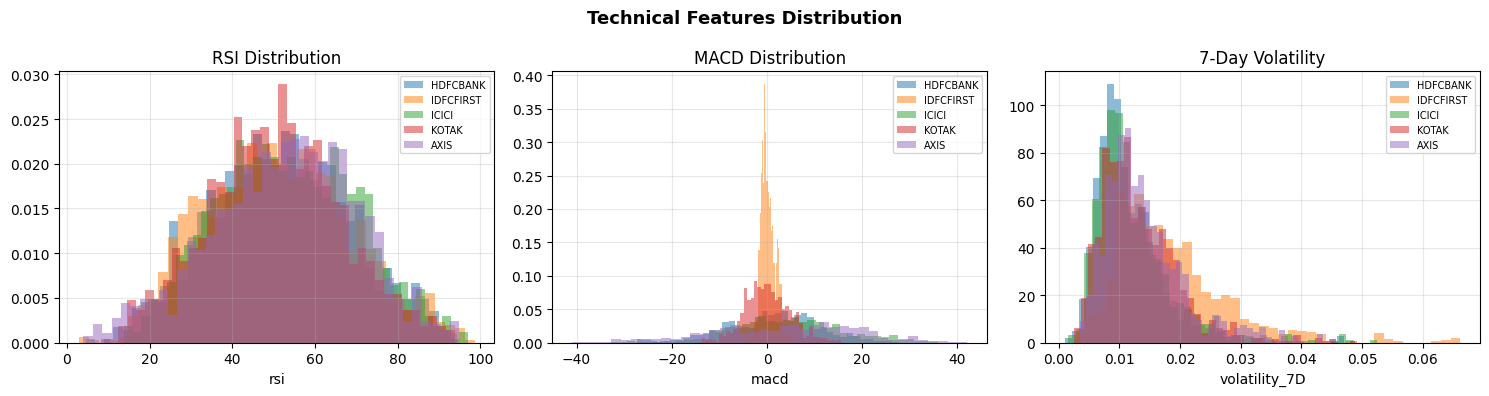

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Technical Features Distribution', fontsize=13, fontweight='bold')

for ax, (feat, title) in zip(axes, [
    ('rsi', 'RSI Distribution'),
    ('macd', 'MACD Distribution'),
    ('volatility_7D', '7-Day Volatility')
]):
    for stock, color in zip(STOCKS, colors):
        vals = full_data[full_data.stock_id == stock][feat].dropna()
        ax.hist(vals, bins=40, alpha=0.5, label=stock, color=color, density=True)
    ax.set_title(title)
    ax.set_xlabel(feat)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 🧩 Section 4 — Label Engineering

**Regression target:** `next_close` — next trading day's closing price  
**Classification target:** `trend` — 3-class label based on next-day return threshold

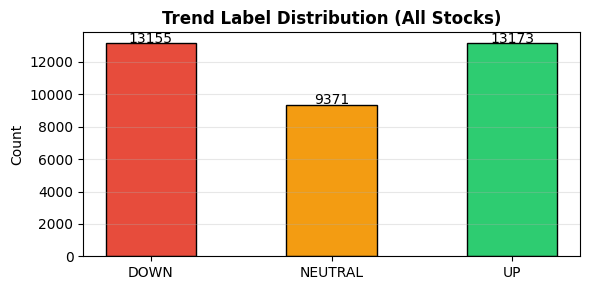

Dataset size after labeling: 35,699


In [6]:
THRESHOLD = 0.005  # 0.5% → define UP / DOWN / NEUTRAL band

dfs = []
for stock_id, grp in full_data.groupby('stock_id'):
    grp = grp.sort_values('date').copy()
    grp['next_close']  = grp['close'].shift(-1)
    grp['next_ret']    = grp['next_close'] / grp['close'] - 1
    grp['trend']       = grp['next_ret'].apply(
        lambda r: 2 if r > THRESHOLD else (0 if r < -THRESHOLD else 1)  # 2=UP, 1=NEUTRAL, 0=DOWN
    )
    dfs.append(grp)

labeled = pd.concat(dfs).dropna(subset=['next_close', 'trend']).reset_index(drop=True)

# Label distribution
label_map = {0: 'DOWN', 1: 'NEUTRAL', 2: 'UP'}
dist = labeled['trend'].value_counts().sort_index()
dist.index = [label_map[i] for i in dist.index]

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(dist.index, dist.values, color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black', width=0.5)
for bar, val in zip(bars, dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val), ha='center', fontsize=10)
ax.set_title('Trend Label Distribution (All Stocks)', fontweight='bold')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Dataset size after labeling: {len(labeled):,}')

---
## 🔧 Section 5 — Sequence Dataset

Sliding window of `SEQ_LEN=20` trading days → predict day 21.

In [7]:
FEATURE_COLS = ['open', 'high', 'low', 'close', 'volume',
                'ret_1D', 'ret_3D', 'ret_7D', 'rsi', 'macd',
                'volatility_7D', 'volume_change']
SEQ_LEN = 20
TRAIN_RATIO = 0.75
VAL_RATIO   = 0.10


class StockSequenceDataset(Dataset):
    """
    Sliding-window time-series dataset.
    Returns (X_seq, y_class, y_reg) per sample.
    """
    def __init__(self, sequences, class_labels, reg_labels):
        self.X   = torch.tensor(sequences,   dtype=torch.float32)
        self.yc  = torch.tensor(class_labels, dtype=torch.long)
        self.yr  = torch.tensor(reg_labels,   dtype=torch.float32)

    def __len__(self):  return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.yc[idx], self.yr[idx]


def build_sequences(df, scaler=None, fit_scaler=False):
    all_X, all_yc, all_yr = [], [], []
    
    for stock_id, grp in df.groupby('stock_id'):
        grp = grp.sort_values('date').reset_index(drop=True)
        feats  = grp[FEATURE_COLS].values
        labels_c = grp['trend'].values
        labels_r = grp['next_close'].values
        
        # ── Clean inf/NaN from real market data ──────────────────────
        feats = pd.DataFrame(feats, columns=FEATURE_COLS)
        feats = feats.replace([np.inf, -np.inf], np.nan)
        feats = feats.ffill().bfill()   # forward-fill gaps, then back-fill any leading NaNs
        feats = feats.values
        # ─────────────────────────────────────────────────────────────

        if fit_scaler and scaler is not None:
            scaler.partial_fit(feats)
        if scaler is not None:
            feats = scaler.transform(feats)
        
        for i in range(SEQ_LEN, len(grp)):
            all_X.append(feats[i-SEQ_LEN:i])
            all_yc.append(labels_c[i])
            all_yr.append(labels_r[i])
    
    return np.array(all_X), np.array(all_yc), np.array(all_yr)


# Chronological split (per stock)
train_dfs, val_dfs, test_dfs = [], [], []
for _, grp in labeled.groupby('stock_id'):
    grp = grp.sort_values('date')
    n  = len(grp)
    t1 = int(n * TRAIN_RATIO)
    t2 = int(n * (TRAIN_RATIO + VAL_RATIO))
    train_dfs.append(grp.iloc[:t1])
    val_dfs.append(grp.iloc[t1:t2])
    test_dfs.append(grp.iloc[t2:])

df_train = pd.concat(train_dfs)
df_val   = pd.concat(val_dfs)
df_test  = pd.concat(test_dfs)

# ── Global safety: remove any inf that slipped through feature engineering ──
for _df in [df_train, df_val, df_test]:
    _df[FEATURE_COLS] = _df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
    _df[FEATURE_COLS] = _df.groupby('stock_id')[FEATURE_COLS].transform(
        lambda x: x.ffill().bfill()
    )
scaler = StandardScaler()
X_tr,  yc_tr,  yr_tr  = build_sequences(df_train, scaler, fit_scaler=True)
X_val, yc_val, yr_val = build_sequences(df_val,   scaler)
X_te,  yc_te,  yr_te  = build_sequences(df_test,  scaler)

# Normalize regression targets (per-stock mean/std)
yr_mean, yr_std = yr_tr.mean(), yr_tr.std()
yr_tr_n  = (yr_tr  - yr_mean) / yr_std
yr_val_n = (yr_val - yr_mean) / yr_std
yr_te_n  = (yr_te  - yr_mean) / yr_std

BATCH = 64
train_loader = DataLoader(StockSequenceDataset(X_tr,  yc_tr,  yr_tr_n),  batch_size=BATCH, shuffle=True,  drop_last=True)
val_loader   = DataLoader(StockSequenceDataset(X_val, yc_val, yr_val_n), batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(StockSequenceDataset(X_te,  yc_te,  yr_te_n),  batch_size=BATCH, shuffle=False)

print(f'Train sequences : {len(X_tr):,}')
print(f'Val sequences   : {len(X_val):,}')
print(f'Test sequences  : {len(X_te):,}')
print(f'Feature dim     : {X_tr.shape[2]}')

Train sequences : 26,207
Val sequences   : 2,996
Test sequences  : 4,816
Feature dim     : 12


---
## 🤖 Section 6 — Dual-Head Transformer Model

```
Input [B, T, F]  →  Linear Projection  →  Positional Encoding
                 →  4× Transformer Encoder Layers
                 →  Global Average Pooling
                 →  ┌────────────────┬────────────────────┐
                    │ Classification │   Regression Head  │
                    │  Head (3-class)│   (next close ₹)   │
                    └────────────────┴────────────────────┘
```

In [8]:
class LSTMDualHead(nn.Module):
    """
    Bidirectional LSTM with dual head for stock trend prediction.
    - Classification head: UP / NEUTRAL / DOWN (3 classes)
    - Regression head:     next-day closing price
    """
    def __init__(self, input_dim, hidden_dim=128, num_layers=3,
                 dropout=0.2, num_classes=3, bidirectional=True):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        # Input projection + normalization
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )

        # Stacked BiLSTM
        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional
        )

        # After BiLSTM, dim = hidden_dim * num_directions
        lstm_out_dim = hidden_dim * self.num_directions  # 256 if bidirectional

        # Attention over time steps
        self.attention = nn.Sequential(
            nn.Linear(lstm_out_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        # Shared representation
        self.shared_mlp = nn.Sequential(
            nn.Linear(lstm_out_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.GELU()
        )

        # Classification head
        self.cls_head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

        # Regression head
        self.reg_head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param.data)   # best practice for recurrent weights
            elif 'bias' in name:
                nn.init.zeros_(param.data)
                # Set forget gate bias to 1 to help gradient flow early in training
                n = param.size(0)
                param.data[n//4 : n//2].fill_(1.0)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def attention_pool(self, lstm_out):
        """Soft attention over T time steps → weighted sum."""
        # lstm_out: [B, T, lstm_out_dim]
        scores = self.attention(lstm_out)          # [B, T, 1]
        weights = torch.softmax(scores, dim=1)     # [B, T, 1]
        context = (weights * lstm_out).sum(dim=1)  # [B, lstm_out_dim]
        return context

    def forward(self, x):
        # x: [B, T, F]
        x = self.input_proj(x)                    # [B, T, hidden_dim]
        lstm_out, _ = self.lstm(x)                # [B, T, hidden_dim * directions]
        context = self.attention_pool(lstm_out)   # [B, lstm_out_dim]
        shared = self.shared_mlp(context)         # [B, 64]

        cls_out = self.cls_head(shared)           # [B, 3]
        reg_out = self.reg_head(shared).squeeze(-1)  # [B]
        return cls_out, reg_out


# Instantiate
INPUT_DIM = len(FEATURE_COLS)
model = LSTMDualHead(
    input_dim=INPUT_DIM,
    hidden_dim=128,
    num_layers=3,
    dropout=0.2,
    bidirectional=True
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal trainable parameters: {total_params:,}')

LSTMDualHead(
  (input_proj): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
  )
  (lstm): LSTM(128, 128, num_layers=3, batch_first=True, dropout=0.2, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (shared_mlp): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): GELU(approximate='none')
  )
  (cls_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=3, bias=True)
  )
  (reg_head): Sequential(
    (0): Linear(in_feat

---
## 🏋️ Section 7 — Training Loop

In [9]:
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score

# ─── Loss & Optimiser ───────────────────────────────────────────
cls_criterion = nn.CrossEntropyLoss()
reg_criterion = nn.HuberLoss(delta=1.0)  # Robust to outliers

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-5)

# Loss weights (tune if needed)
ALPHA = 0.6   # classification weight
BETA  = 0.4   # regression weight


def run_epoch(loader, train=True):
    model.train(train)
    total_loss, total_cls_loss, total_reg_loss = 0, 0, 0
    correct, total = 0, 0
    
    # Track regression metrics
    all_reg_preds, all_reg_true = [], []
    
    with torch.set_grad_enabled(train):
        for X, yc, yr in loader:
            X, yc, yr = X.to(DEVICE), yc.to(DEVICE), yr.to(DEVICE)
            
            cls_logits, reg_pred = model(X)
            
            loss_cls = cls_criterion(cls_logits, yc)
            loss_reg = reg_criterion(reg_pred, yr)
            loss = ALPHA * loss_cls + BETA * loss_reg
            
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            
            total_loss     += loss.item() * len(X)
            total_cls_loss += loss_cls.item() * len(X)
            total_reg_loss += loss_reg.item() * len(X)
            correct += (cls_logits.argmax(1) == yc).sum().item()
            total   += len(X)
            
            # Collect regression predictions for MAE & R²
            all_reg_preds.extend(reg_pred.detach().cpu().numpy())
            all_reg_true.extend(yr.detach().cpu().numpy())
    
    n = total
    
    # Compute regression metrics
    all_reg_preds = np.array(all_reg_preds)
    all_reg_true = np.array(all_reg_true)
    reg_mae = mean_absolute_error(all_reg_true, all_reg_preds)
    reg_r2 = r2_score(all_reg_true, all_reg_preds)
    # reg_acc = accuracy_score(all_reg_true, all_reg_preds)
    
    cls_acc = correct / n
    
    return (total_loss/n, total_cls_loss/n, total_reg_loss/n, cls_acc, reg_mae, reg_r2)

In [10]:
# ─── Training ───────────────────────────────────────────────────
EPOCHS = 60
history = {
    'train_loss': [], 'val_loss': [],
    'train_cls_acc': [], 'val_cls_acc': [],
    'train_reg_mae': [], 'val_reg_mae': [],
    'train_reg_r2': [], 'val_reg_r2': [],
    'lr': []
}
best_val_loss = float('inf')
best_cls_val_acc = float('inf')
best_reg_val_mae = float('inf')
best_state    = None
patience, patience_cnt = 8, 0

print('🚀 Starting training...\n')

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_cls, tr_reg, tr_cls_acc, tr_reg_mae, tr_reg_r2 = run_epoch(train_loader, train=True)
    va_loss, va_cls, va_reg, va_cls_acc, va_reg_mae, va_reg_r2 = run_epoch(val_loader,   train=False)
    scheduler.step()
    
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_cls_acc'].append(tr_cls_acc)
    history['val_cls_acc'].append(va_cls_acc)
    history['train_reg_mae'].append(tr_reg_mae)
    history['val_reg_mae'].append(va_reg_mae)
    history['train_reg_r2'].append(tr_reg_r2)
    history['val_reg_r2'].append(va_reg_r2)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_cnt  = 0
    else:
        patience_cnt += 1
    
    # Log to Weights & Biases
    # wandb.log({
    #     'train/loss': tr_loss,
    #     'train/cls_loss': tr_cls,
    #     'train/reg_loss': tr_reg,
    #     'train/accuracy': tr_acc,
    #     'val/loss': va_loss,
    #     'val/cls_loss': va_cls,
    #     'val/reg_loss': va_reg,
    #     'val/accuracy': va_acc,
    #     'learning_rate': optimizer.param_groups[0]['lr'],
    #     'epoch': epoch,
    #     'patience_counter': patience_cnt,
    # })
    
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:02d}/{EPOCHS} | '
              f'Train Loss: {tr_loss:.4f} | '
              f'Val Loss: {va_loss:.4f} | '
              f'Train Cls Acc: {tr_cls_acc:.3f} | Val Cls Acc: {va_cls_acc:.3f} | '
              f'Train Reg MAE: {tr_reg_mae:.4f} | Val Reg MAE: {va_reg_mae:.4f} | '
              f'Train R²: {tr_reg_r2:.4f} | Val R²: {va_reg_r2:.4f} | '
              f'LR: {history["lr"][-1]:.2e}')
    
    if patience_cnt >= patience:
        print(f'\n⏸️  Early stopping at epoch {epoch} (no improvement for {patience} epochs)')
        break

# Restore best weights
model.load_state_dict(best_state)
print(f'\n✅ Best Val Loss: {best_val_loss:.4f}')

# Log final metrics
# wandb.log({'best_val_loss': best_val_loss, 'final_epoch': epoch})
# wandb.alert(
#     title="Training Completed",
#     text=f"Best validation loss: {best_val_loss:.4f}",
#     level="info"
# )

🚀 Starting training...

Epoch 01/60 | Train Loss: 0.6758 | Val Loss: 0.6722 | Train Cls Acc: 0.372 | Val Cls Acc: 0.381 | Train Reg MAE: 0.2363 | Val Reg MAE: 0.2396 | Train R²: 0.8754 | Val R²: 0.9170 | LR: 9.97e-04
Epoch 05/60 | Train Loss: 0.6500 | Val Loss: 0.6597 | Train Cls Acc: 0.387 | Val Cls Acc: 0.389 | Train Reg MAE: 0.1008 | Val Reg MAE: 0.1499 | Train R²: 0.9787 | Val R²: 0.9547 | LR: 9.34e-04
Epoch 10/60 | Train Loss: 0.6436 | Val Loss: 0.6635 | Train Cls Acc: 0.406 | Val Cls Acc: 0.391 | Train Reg MAE: 0.0828 | Val Reg MAE: 0.1679 | Train R²: 0.9870 | Val R²: 0.9451 | LR: 7.53e-04

⏸️  Early stopping at epoch 12 (no improvement for 8 epochs)

✅ Best Val Loss: 0.6576


---
## 📊 Section 8 — Training Curves

KeyError: 'train_acc'

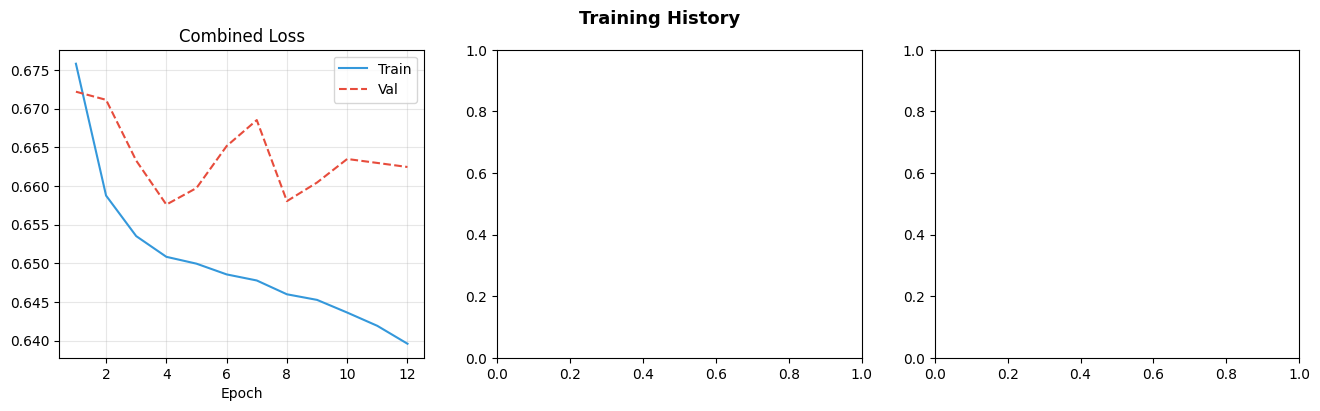

In [11]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Training History', fontsize=13, fontweight='bold')

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train', color='#3498db')
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='#e74c3c', linestyle='--')
axes[0].set_title('Combined Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], label='Train', color='#2ecc71')
axes[1].plot(epochs_range, history['val_acc'],   label='Val',   color='#e67e22', linestyle='--')
axes[1].set_title('Classification Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# LR schedule
axes[2].plot(epochs_range, history['lr'], color='#9b59b6')
axes[2].set_title('Learning Rate (Cosine Decay)')
axes[2].set_xlabel('Epoch')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 🧪 Section 9 — Test Evaluation

### 9.1 Classification: Trend Direction

In [ ]:
model.eval()
all_preds_c, all_true_c = [], []
all_preds_r, all_true_r = [], []

with torch.no_grad():
    for X, yc, yr in test_loader:
        X = X.to(DEVICE)
        cls_logits, reg_pred = model(X)
        all_preds_c.extend(cls_logits.argmax(1).cpu().numpy())
        all_true_c.extend(yc.numpy())
        all_preds_r.extend(reg_pred.cpu().numpy())
        all_true_r.extend(yr.numpy())

all_preds_c = np.array(all_preds_c)
all_true_c  = np.array(all_true_c)
all_preds_r = np.array(all_preds_r) * yr_std + yr_mean   # denormalise
all_true_r  = np.array(all_true_r)  * yr_std + yr_mean

# Classification report
print('=' * 50)
print('CLASSIFICATION REPORT — Trend Direction')
print('=' * 50)
print(classification_report(all_true_c, all_preds_c,
                             target_names=['DOWN', 'NEUTRAL', 'UP']))

# Confusion matrix
cm = confusion_matrix(all_true_c, all_preds_c)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1,2]); ax.set_xticklabels(['DOWN','NEUTRAL','UP'])
ax.set_yticks([0,1,2]); ax.set_yticklabels(['DOWN','NEUTRAL','UP'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix', fontweight='bold')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=12)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### 9.2 Regression: Next-Day Close Price

In [ ]:
mae  = mean_absolute_error(all_true_r, all_preds_r)
r2   = r2_score(all_true_r, all_preds_r)
mape = np.mean(np.abs((all_true_r - all_preds_r) / (all_true_r + 1e-9))) * 100

print('=' * 50)
print('REGRESSION METRICS — Next-Day Close Price')
print('=' * 50)
print(f'  MAE  : ₹{mae:.2f}')
print(f'  MAPE : {mape:.2f}%')
print(f'  R²   : {r2:.4f}')

# Scatter: actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(all_true_r[:500], all_preds_r[:500], alpha=0.4, s=10, color='#2980b9')
mn, mx = min(all_true_r.min(), all_preds_r.min()), max(all_true_r.max(), all_preds_r.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Close (₹)')
axes[0].set_ylabel('Predicted Close (₹)')
axes[0].set_title(f'Actual vs Predicted  (R² = {r2:.3f})', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Time-series overlay (first 120 test points)
n_show = 120
axes[1].plot(all_true_r[:n_show],  label='Actual',    color='#2ecc71', linewidth=1.5)
axes[1].plot(all_preds_r[:n_show], label='Predicted', color='#e74c3c', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Test Sample Index')
axes[1].set_ylabel('Close Price (₹)')
axes[1].set_title('Predicted vs Actual (Test Set — first 120 pts)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 🔬 Section 10 — Per-Stock Evaluation

In [ ]:
# Rebuild test data with stock_id tracking
test_records = []
for stock_id, grp in df_test.groupby('stock_id'):
    grp = grp.sort_values('date').reset_index(drop=True)
    for i in range(SEQ_LEN, len(grp)):
        test_records.append({
            'stock_id': stock_id,
            'date'    : grp['date'].iloc[i],
            'true_cls': int(grp['trend'].iloc[i]),
            'true_reg': float(grp['next_close'].iloc[i])
        })

test_meta = pd.DataFrame(test_records)
test_meta['pred_cls'] = all_preds_c
test_meta['pred_reg'] = all_preds_r

print('Per-Stock Accuracy & MAE on Test Set:')
print('-' * 45)
stock_metrics = []
for stock_id, grp in test_meta.groupby('stock_id'):
    acc  = (grp['pred_cls'] == grp['true_cls']).mean()
    mae_ = mean_absolute_error(grp['true_reg'], grp['pred_reg'])
    stock_metrics.append({'Stock': stock_id, 'Accuracy': acc, 'MAE (₹)': mae_})
    print(f'  {stock_id:12s} | Accuracy: {acc:.3f} | MAE: ₹{mae_:.2f}')

sm = pd.DataFrame(stock_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(sm['Stock'], sm['Accuracy'], color=colors, edgecolor='black')
axes[0].set_title('Per-Stock Classification Accuracy', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].axhline(sm['Accuracy'].mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(sm['Stock'], sm['MAE (₹)'], color=colors, edgecolor='black')
axes[1].set_title('Per-Stock Regression MAE (₹)', fontweight='bold')
axes[1].set_ylabel('MAE (₹)')
axes[1].axhline(sm['MAE (₹)'].mean(), color='red', linestyle='--', label='Mean')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 🔮 Section 11 — Inference: Predict on Latest Data

In [ ]:
TREND_LABELS = {0: '🔴 DOWN', 1: '🟡 NEUTRAL', 2: '🟢 UP'}

def predict_latest(stock_id, df=labeled, scaler=scaler,
                   yr_mean=yr_mean, yr_std=yr_std):
    """
    Predict trend & next close for the most recent window of a stock.
    """
    grp = df[df['stock_id'] == stock_id].sort_values('date').tail(SEQ_LEN)
    if len(grp) < SEQ_LEN:
        print(f'Not enough data for {stock_id}')
        return
    
    feats = scaler.transform(grp[FEATURE_COLS].values)  # [SEQ_LEN, F]
    X = torch.tensor(feats, dtype=torch.float32).unsqueeze(0).to(DEVICE)  # [1, T, F]
    
    model.eval()
    with torch.no_grad():
        cls_logits, reg_pred = model(X)
    
    probs      = torch.softmax(cls_logits, dim=-1).cpu().numpy()[0]
    trend_idx  = int(cls_logits.argmax(1).item())
    next_close = float(reg_pred.item()) * yr_std + yr_mean
    curr_close = float(grp['close'].iloc[-1])
    
    print(f'\n┌─ {stock_id} ─────────────────────────────────')
    print(f'│  Current Close   : ₹{curr_close:,.2f}')
    print(f'│  Predicted Close : ₹{next_close:,.2f}')
    print(f'│  Predicted Trend : {TREND_LABELS[trend_idx]}')
    print(f'│  Probabilities   : DOWN={probs[0]:.2f}  NEUTRAL={probs[1]:.2f}  UP={probs[2]:.2f}')
    print(f'└──────────────────────────────────────────────')
    return {'stock': stock_id, 'current': curr_close, 'predicted': next_close,
            'trend': TREND_LABELS[trend_idx], 'probs': probs}


# Run inference on all banking stocks
print('📊 NEXT-DAY PREDICTIONS — Banking Sector')
results = [predict_latest(s) for s in STOCKS]

---
## 💾 Section 12 — Save & Load Model

In [ ]:
import os, pickle

SAVE_DIR = 'saved_model'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save model weights
torch.save(model.state_dict(), f'{SAVE_DIR}/dual_head_transformer.pt')

# Save scaler + normalisation stats
with open(f'{SAVE_DIR}/scaler.pkl', 'wb') as f:
    pickle.dump({'scaler': scaler, 'yr_mean': yr_mean, 'yr_std': yr_std}, f)

print(f'Model saved to ./{SAVE_DIR}/')
print(f'  dual_head_transformer.pt  — PyTorch weights')
print(f'  scaler.pkl                — Feature scaler + regression normalisation')

In [ ]:
# ─── How to reload the model ────────────────────────────────────
# new_model = DualHeadTransformer(input_dim=INPUT_DIM).to(DEVICE)
# new_model.load_state_dict(torch.load(f'{SAVE_DIR}/dual_head_transformer.pt', map_location=DEVICE))
# new_model.eval()
#
# with open(f'{SAVE_DIR}/scaler.pkl', 'rb') as f:
#     artifacts = pickle.load(f)
#     scaler   = artifacts['scaler']
#     yr_mean  = artifacts['yr_mean']
#     yr_std   = artifacts['yr_std']

print('Reload snippet is ready — uncomment to use.')

---
## 📝 Next Steps & Customisation Guide

| Area | What to change |
|---|---|
| **Real data** | Replace `generate_price_data()` with `yfinance` or NSE API calls |
| **More stocks** | Add tickers to `STOCKS` list (IT sector: INFY, TCS, WIPRO) |
| **Sequence length** | Tune `SEQ_LEN` (try 10, 30, 60 days) |
| **Architecture** | Increase `num_layers` / `d_model` for more capacity |
| **More features** | Add Bollinger Bands, OBV, ADX to `FEATURE_COLS` |
| **Class weights** | Pass `weight=` to `CrossEntropyLoss` if class imbalance is high |
| **Deployment** | Export with `torch.jit.script(model)` for serving |

---
*Model: Dual-Head Temporal Transformer | Sector: Banking | Author: Stock Prediction Project*